In [16]:
import numpy as np
import torch
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.patches as mpatches

sys.path.insert(0, str(pathlib.Path("..").resolve()))

from models.tempo import TEMPOTrainer, TEMPOConfig, pod_factory, fourier_pod_factory
from models.pod import PODConfig
from models.fourier_neural_pod import FourierNeuralPODConfig
from utils.datasets import load, download
import umap

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
DEVICE


def draw_cov_ellipse(ax, mean2d, cov2d, color, n_std=2.0, **kwargs):
    """Draw covariance ellipse from 2x2 covariance matrix"""
    vals, vecs = np.linalg.eigh(cov2d)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ellipse = Ellipse(mean2d, w, h, angle=angle,
                      edgecolor=color, facecolor="none", lw=2, **kwargs)
    ax.add_patch(ellipse)

In [8]:
nu_values = [0.001, 0.01, 0.1, 1.0]
N_samples  = 5000

In [9]:
tensors, kappas, ts = [], [], []

for nu in nu_values:
    data = load(f"Burgers_Nu{nu}")
    u = data["tensor"][:N_samples, :, :, 0]   # (N_samples, Nt, Nx)
    t_np = data["t-coordinate"]                # (Nt,)
    x_np = data["x-coordinate"]               # (Nx,)

    N, Nt, Nx = u.shape
    u_flat = u.reshape(-1, Nx)                 # (N*Nt, Nx)
    t_flat = np.tile(t_np, N)                  # (N*Nt,)
    k_flat = np.full(len(t_flat), nu)          # (N*Nt,)

    tensors.append(u_flat)
    kappas.append(k_flat)
    ts.append(t_flat)


s_np     = np.concatenate(tensors, axis=0)    # (N_total, Nx)
t_np_all = np.concatenate(ts,      axis=0)    # (N_total,)
k_np_all = np.concatenate(kappas,  axis=0)    # (N_total,)

s     = torch.tensor(s_np,                dtype=torch.float32, device=DEVICE)
t     = torch.tensor(t_np_all,            dtype=torch.float32, device=DEVICE)
x     = torch.tensor(x_np[:, None],       dtype=torch.float32, device=DEVICE)
kappa = torch.tensor(k_np_all[:, None],   dtype=torch.float32, device=DEVICE)
gamma = torch.ones(len(s), dtype=torch.float32, device=DEVICE) / len(s)

In [10]:
print(f"s={s.shape}, t={t.shape}, x={x.shape}, kappa={kappa.shape}")

s=torch.Size([5120000, 101]), t=torch.Size([5120000]), x=torch.Size([101, 1]), kappa=torch.Size([5120000, 1])


In [11]:
cfg = TEMPOConfig(
    M=3,
    P_global=8,
    sigma2=0.1,
    max_em_iters=10,
    eps_skip=0.01,
    eps_large=0.1,
    eps_conv=0.005,
    basis_config=PODConfig(max_modes=5),
    basis_factory=pod_factory,
)

In [12]:
trainer = TEMPOTrainer(cfg)
trainer.train(s, x, t, kappa)

POD | N=5120000, Ny=101 | max_modes=8, tol=1.0
  P=8 modes (100.00% variance threshold, needed 101)
  mode  1: sigma=6.0442e+00  cumvar=92.56%  res_mse=2.9097e-02
  mode  2: sigma=1.0713e+00  cumvar=95.47%  res_mse=1.7727e-02
  mode  3: sigma=7.3076e-01  cumvar=96.83%  res_mse=1.2423e-02
  mode  4: sigma=5.4963e-01  cumvar=97.59%  res_mse=9.4165e-03
  mode  5: sigma=4.4937e-01  cumvar=98.10%  res_mse=7.4124e-03
  mode  6: sigma=3.7718e-01  cumvar=98.46%  res_mse=6.0061e-03
  mode  7: sigma=3.2399e-01  cumvar=98.73%  res_mse=4.9692e-03
  mode  8: sigma=2.8003e-01  cumvar=98.93%  res_mse=4.1923e-03
  done: final res_mse=4.1923e-03
POD | N=5120000, Ny=101 | max_modes=5, tol=0.9999
  P=5 modes (99.99% variance threshold, needed 67)
  mode  1: sigma=9.1872e+00  cumvar=97.76%  res_mse=2.9154e-02
  mode  2: sigma=7.8453e-01  cumvar=98.48%  res_mse=2.2508e-02
  mode  3: sigma=6.1310e-01  cumvar=98.91%  res_mse=1.9024e-02
  mode  4: sigma=4.2221e-01  cumvar=99.12%  res_mse=1.6926e-02
  mode  5:

Results:

In [18]:
N_viz      = 8000
idx_viz    = np.random.choice(len(s), N_viz, replace=False)

alpha_np   = trainer.alpha.cpu().float().numpy()
alpha_viz  = alpha_np[idx_viz]
kappa_viz  = kappa[idx_viz, 0].cpu().numpy()
hard_all   = trainer.gamma.argmax(dim=1).cpu().numpy()
hard_viz   = hard_all[idx_viz]
mu_np      = trainer.mu.cpu().float().numpy()   # (M, P)

Umap:

In [19]:
reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(alpha_viz)
mu_umap   = reducer.transform(mu_np)

/Users/rknza/research/m1p/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plots:

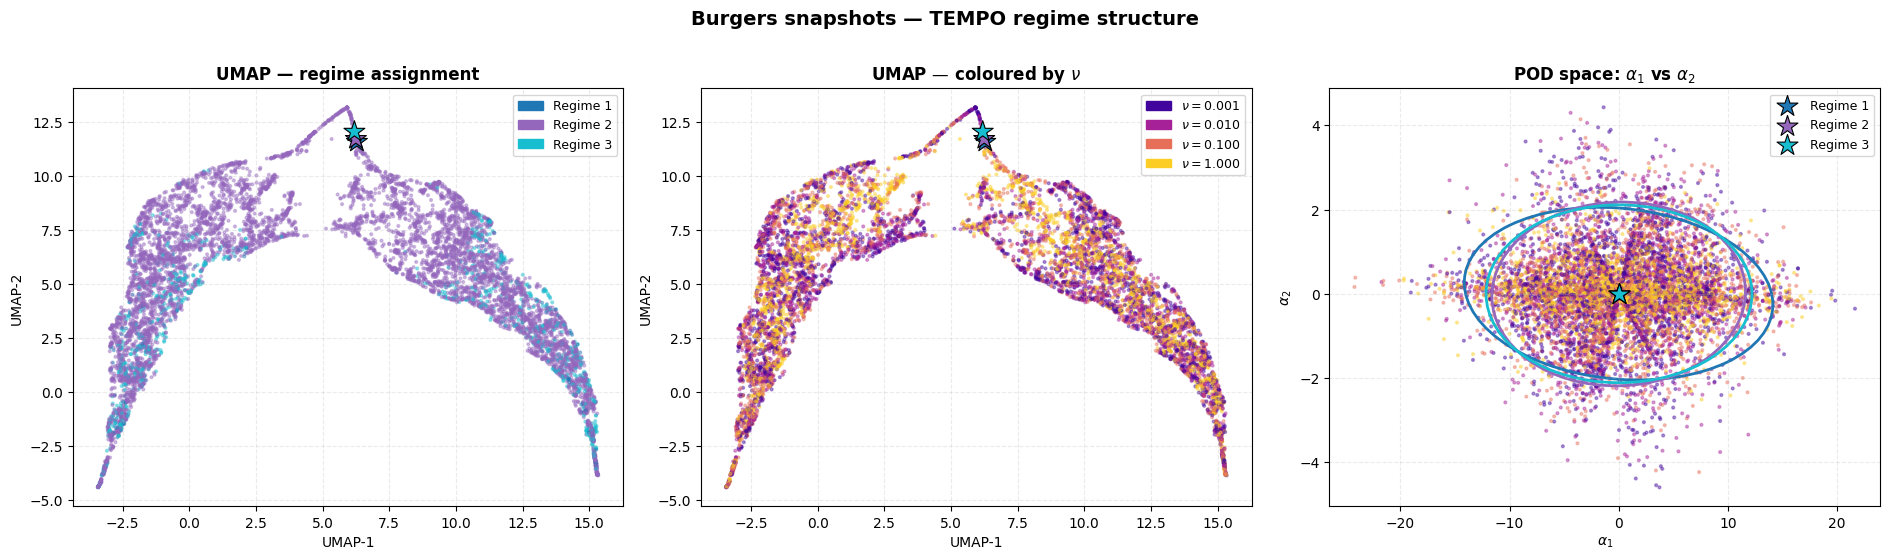

In [20]:
regime_colors = plt.cm.tab10(np.linspace(0, 0.9, cfg.M))

nu_unique  = np.unique(kappa_viz)
nu_palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(nu_unique)))
nu_to_col  = {nu: c for nu, c in zip(nu_unique, nu_palette)}
nu_colors  = np.array([nu_to_col[float(nu)] for nu in kappa_viz])


fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

star_kw = dict(s=250, marker="*", edgecolors="black", linewidths=0.8, zorder=6)

# Panel 1: UMAP coloured by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_viz], s=4, alpha=0.4, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1],
                c=regime_colors, **star_kw)
axes[0].set_title("UMAP — regime assignment", fontweight="bold")
handles = [mpatches.Patch(color=regime_colors[m], label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 2: UMAP coloured by nu
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=nu_colors, s=4, alpha=0.4, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1],
                c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP — coloured by $\nu$", fontweight="bold")
handles = [mpatches.Patch(color=nu_to_col[nu], label=rf"$\nu = {nu:.3f}$")
           for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 3: POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=nu_colors, s=4, alpha=0.4, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m])
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw,
                    label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.25)
    ax.set_aspect("auto")

plt.suptitle(r"Burgers snapshots — TEMPO regime structure",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()